In [1]:

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np


In [2]:



(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


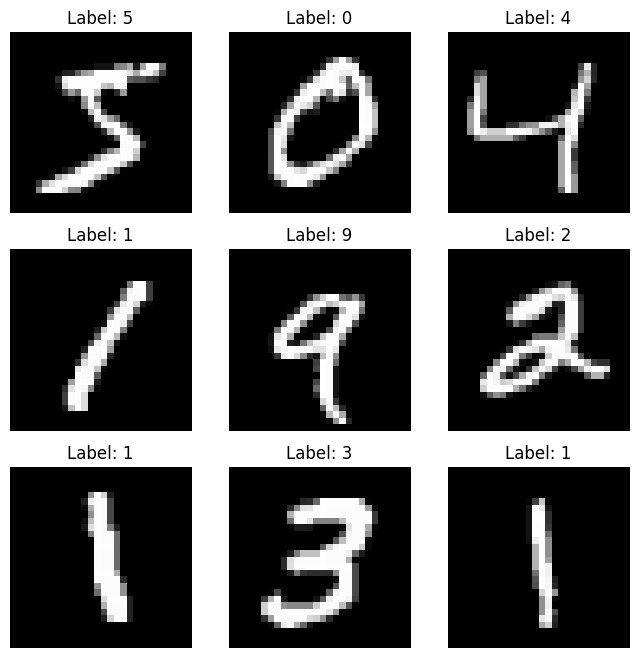

In [3]:


plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()



In [4]:

x_train = x_train / 255.0
x_test = x_test / 255.0


model = keras.Sequential([

    keras.layers.Flatten(input_shape=(28,28)),   # Convert 2D → 1D

    keras.layers.Dense(128, activation='relu'),  # Hidden layer

    keras.layers.Dense(10, activation='softmax') # Output layer
])



C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9271 - loss: 0.2572 - val_accuracy: 0.9587 - val_loss: 0.1401
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9661 - loss: 0.1121 - val_accuracy: 0.9670 - val_loss: 0.1080
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9765 - loss: 0.0777 - val_accuracy: 0.9713 - val_loss: 0.1000
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9822 - loss: 0.0581 - val_accuracy: 0.9738 - val_loss: 0.0853
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9864 - loss: 0.0437 - val_accuracy: 0.9748 - val_loss: 0.0855
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9776 - val_loss: 0.0767
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9907 - loss: 0.0291 - val_accuracy: 0.9781 - val_loss: 0.0783
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9924 - loss: 0.0235 - 

In [6]:

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0861
Test Accuracy: 0.9781000018119812


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


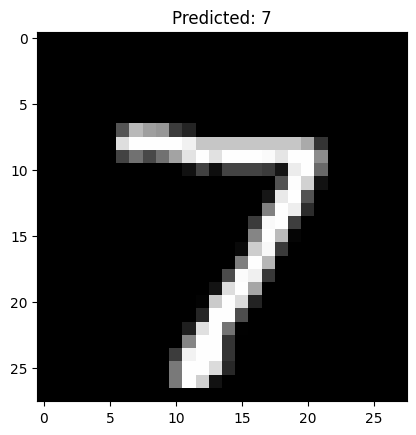

In [7]:

predictions = model.predict(x_test)

plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[0])))
plt.show()

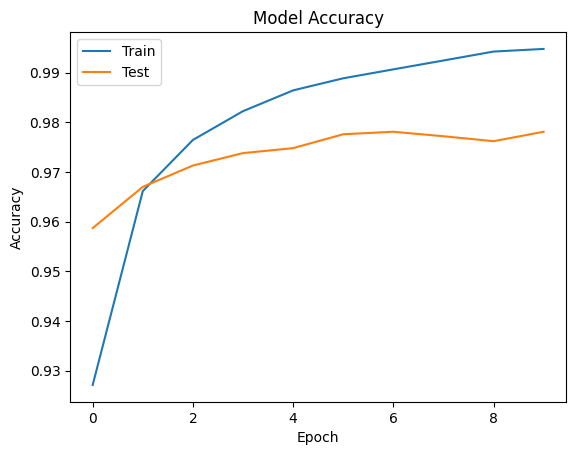

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Test'])
plt.show()